EJERCICIO N° 1 REGRESIÓN y MUTUAL INFORMATION (MI):

Regresión y MUTUAL INFORMATION para Problemas de Regresión

Averigüe si hay relación entre las variables siguientes:
Clump thickness    Unif_Cell_Size    Unif_Cell_Shape    Marginal_Adhesion

Emplee ambos métodos.


---




BIBLIOTECAS

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from scipy.stats import pearsonr

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Analisis de la informacion/Ejercicio N°1 Regresión y MI/Aprendizaje_breast-cancer-wisconsin (1).tab', sep='\t')
df

,Clump thickness,Unif_Cell_Size,Unif_Cell_Shape,Marginal_Adhesion,Single_Cell_Size,Bare_Nuclei,Bland_Chromatine,Normal_Nucleoli,Mitoses,type,Selected
0,9.67,9.96,9.27,2.40,9.49,7.93,7.90,0.33,0.06,malign,No
1,0.14,0.15,0.47,0.82,1.71,0.19,2.22,0.55,0.49,benign,No
2,0.61,0.49,0.99,0.19,1.98,0.27,2.07,0.71,0.28,benign,No
3,7.29,1.11,3.42,0.07,4.63,0.25,4.17,3.76,3.11,malign,No
4,6.03,2.47,1.64,9.15,4.48,9.86,4.43,3.58,3.73,malign,No
...,...,...,...,...,...,...,...,...,...,...,...
578,5.00,4.92,4.65,5.29,2.63,9.22,2.81,0.78,0.13,malign,No
579,4.66,1.91,2.22,0.28,5.07,9.36,4.67,0.76,0.90,malign,No
580,2.90,0.77,0.24,3.74,2.32,0.23,1.19,1.12,0.94,benign,No
581,4.72,0.04,0.46,2.62,1.39,0.50,0.70,0.86,0.92,benign,No


En este dataset, el cual llamamos Aprendizaje_breast-cancer-wisconsin, tenemos una serie de variables predictoras continuas X= {Clump thickness, Unif_Cell_Size,	Unif_Cell_Shape,	Marginal_Adhesion, .....} que tratan de explicar a la variable objetivo target 'y' que es categórica.

Este conjunto de datos está basado en la obtención de diferentes métricas a partir de un problema real, que consiste en un trabajo hecho en imágenes sobre tumores.

Estas variables/features X (columnas) representan un conjunto de muestras biológicas, posiblemente relacionadas con un estudio de cáncer (tumor). Cada fila va a representar una muestra individual.

Por ejemplo, desde 'Clump thickness' hasta 'Mitoses', estas columnas corresponderian a medidas celulares que se utilizan comúnmente en la evaluación de muestras de tejido para el diagnóstico de cáncer. Cada una de estas medidas proporciona información sobre diferentes aspectos de las células, como su tamaño, forma, número de núcleos, entre otras.

En el caso de 'type', nos indicaría la clase o tipo de muestra, es decir, si es benigna (no cancerosa) o maligna (cancerosa). Esta columna sería nuestro target o 'y'.

Aplicamos el método .describe() para ver rápidamente la distribución de los datos

In [ ]:
df.describe()

,Clump thickness,Unif_Cell_Size,Unif_Cell_Shape,Marginal_Adhesion,Single_Cell_Size,Bare_Nuclei,Bland_Chromatine,Normal_Nucleoli,Mitoses
count,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000
mean,3.942899,2.643808,2.716123,2.320635,2.707616,3.073756,2.904734,2.315437,1.106106
std,2.839102,3.065228,3.002309,2.862875,2.195023,3.653948,2.384558,2.982279,1.754511
min,0.010000,0.000000,0.000000,0.000000,0.020000,0.000000,0.010000,0.010000,0.000000
25%,1.680000,0.460000,0.470000,0.410000,1.360000,0.450000,1.195000,0.425000,0.310000
50%,3.540000,0.920000,0.990000,0.870000,1.780000,0.860000,2.200000,0.800000,0.600000
75%,5.340000,4.035000,4.445000,3.080000,3.335000,5.650000,3.970000,2.950000,0.900000
max,10.000000,9.990000,10.000000,9.980000,9.960000,9.990000,9.970000,10.000000,9.920000


Ahora vamos a ver las distintas clases que asume el target 'y'.

In [ ]:
df['type'].unique()

array(['malign', 'benign'], dtype=object)

Convierto la columna 'type' a binario con .replace(), asignándoles un valor numérico 0 a maligno y 1 a benigno, para poder trabajar con ella.

In [ ]:
# Convierto 'type' a binario
df['type'] = df['type'].replace({'malign': 0, 'benign': 1})
df

<ipython-input-5-67514f5c23c5>:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['type'] = df['type'].replace({'malign': 0, 'benign': 1})


,Clump thickness,Unif_Cell_Size,Unif_Cell_Shape,Marginal_Adhesion,Single_Cell_Size,Bare_Nuclei,Bland_Chromatine,Normal_Nucleoli,Mitoses,type,Selected
0,9.67,9.96,9.27,2.40,9.49,7.93,7.90,0.33,0.06,0,No
1,0.14,0.15,0.47,0.82,1.71,0.19,2.22,0.55,0.49,1,No
2,0.61,0.49,0.99,0.19,1.98,0.27,2.07,0.71,0.28,1,No
3,7.29,1.11,3.42,0.07,4.63,0.25,4.17,3.76,3.11,0,No
4,6.03,2.47,1.64,9.15,4.48,9.86,4.43,3.58,3.73,0,No
...,...,...,...,...,...,...,...,...,...,...,...
578,5.00,4.92,4.65,5.29,2.63,9.22,2.81,0.78,0.13,0,No
579,4.66,1.91,2.22,0.28,5.07,9.36,4.67,0.76,0.90,0,No
580,2.90,0.77,0.24,3.74,2.32,0.23,1.19,1.12,0.94,1,No
581,4.72,0.04,0.46,2.62,1.39,0.50,0.70,0.86,0.92,1,No


Como vemos, el target se divide en 2 tipos de tumores: Maligno y Benigno.

Nuestro objetivo es determinar si existe relación o no entre las variables continuas 'Clump thickness', 'Unif_Cell_Size', 'Unif_Cell_Shape' y 'Marginal_Adhesion'.

Para ello, vamos a usar dos métodos: unos es el 'Mutual Information' (información mutua), ya trabajado anteriormente, donde se aplica en cada una de las variables continuas respecto a la variable objetivo, sin la necesidad de que se cumplan ciertas condiciones. Y el otro  método es el de Regresión, donde analizaremos la relación y la linealidad de las variables, a través del coeficiente de correlación de Pearson.  

Como solamente trabajaremos con las columnas 'Clump thickness', 'Unif_Cell_Size', 'Unif_Cell_Shape' y 'Marginal_Adhesion', procederemos a eliminar el resto para mayor simplicidad.

In [ ]:
columnas_eliminar = ['Selected', 'Single_Cell_Size', 'Bare_Nuclei', 'Bland_Chromatine', 'Normal_Nucleoli', 'Mitoses']
df = df.drop(columns=columnas_eliminar, axis=1)
df

,Clump thickness,Unif_Cell_Size,Unif_Cell_Shape,Marginal_Adhesion,type
0,9.67,9.96,9.27,2.40,0
1,0.14,0.15,0.47,0.82,1
2,0.61,0.49,0.99,0.19,1
3,7.29,1.11,3.42,0.07,0
4,6.03,2.47,1.64,9.15,0
...,...,...,...,...,...
578,5.00,4.92,4.65,5.29,0
579,4.66,1.91,2.22,0.28,0
580,2.90,0.77,0.24,3.74,1
581,4.72,0.04,0.46,2.62,1


Primero observaremos gráficamente como se comportan las variables X

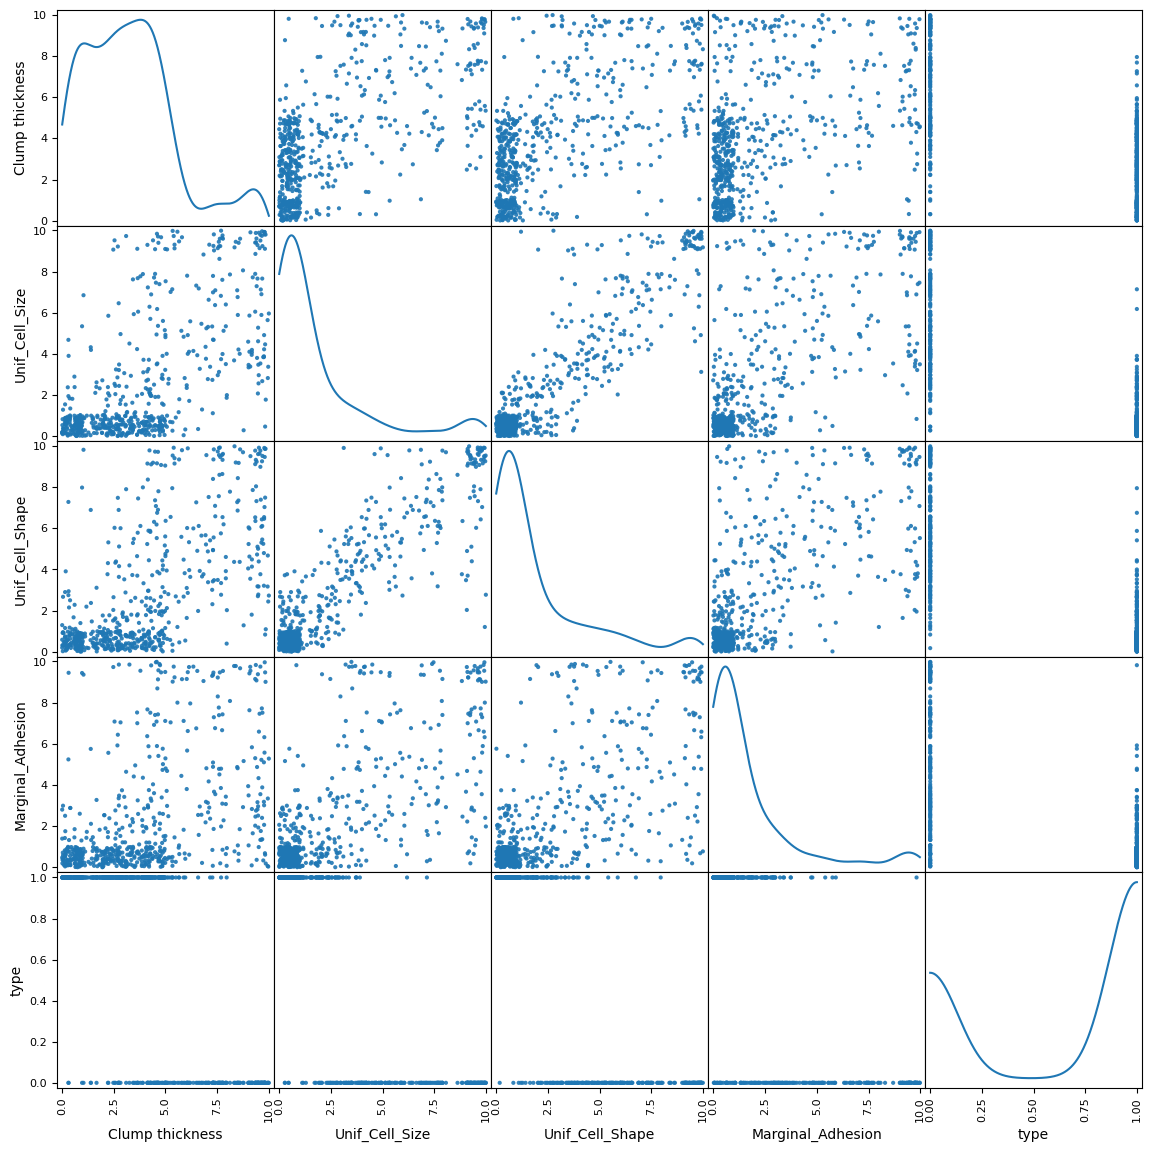

In [ ]:
from pandas.plotting import scatter_matrix
# colores=np.where(df_datos['class']==0,'blue','red')
scatter_matrix(df, alpha=0.9, figsize=(14, 14), diagonal="kde"); #,c=colores, s=10);


A simple vista podemos decir que las variables Unif_Cell_Size y Unif_Cell_Shape tendrian cierta linealidad entre ellas. Sin embargo, para el resto de las variables, visualmente no podemos afirmar que presenten alguna linealidad ya que los puntos se encuentran más dispersos. De esta manera, para poder tener más certeza vamos a utilizar el coeficiente de correlacion de Pearson.

Al aplicar el método de Correlación de Pearson analizamos la linealidad de las variables, donde este coeficiente de correlación r es un valor entre -1 y 1 que nos indicará si dos variables cuantitativas están linealmente relacionadas.

Para calcular este coeficiente usaremos la librería Scipy, la cual obtendremos dos valores: primero 'r' que sería el coeficiente de correlación (estimador) y segundo 'p' que representaría la probabilidad de que r se hubiera obtenido siendo verdadera la Hipótesis Nula.


PLANTEO DE HIPÓTESIS

Lo que se busca demostrar en este problema es si hay alguna relación o no entre las variables xi. Para ello planteamos las siguientes hipótesis:

H1 : "Existe relación entre las variables xi" (hipótesis alternativa)

Ho : "No existe relación entre las variables xi" (hipótesis nula)

Cálculo de la correlación entre las variables xi con Pearson

In [ ]:
# Variable Clump thickness vs Unif_Cell_Size

alfa = 0.05                             # Nivel de significancia o α(alpha)
r,p = pearsonr(x=df['Clump thickness'], y=df['Unif_Cell_Size'])

print("r:", r)
print("p: ",p)
print("alfa: ", alfa)
if p<=alfa:
    print("Como p < alfa existe relación lineal entre la variable Clump thickness y Unif_Cell_Size (es posible rechazar la Hipótesis Nula)")
else:
    print("No es posible rechazar la Hipótesis Nula, por lo tanto asumiremos que no existe relación lineal entre las variables")

r: 0.6395460303454261
p:  2.263622590641568e-68
alfa:  0.05
Como p < alfa existe relación lineal entre la variable Clump thickness y Unif_Cell_Size (es posible rechazar la Hipótesis Nula)


Por conveniencia empleamos un nivel de significancia (o alpha) de 0.05, equivalente al 5%.

Como la probabilidad que obtenemos (p=2.26e-68) es demasiado chica, y por lo tanto menor al nivel de significancia. Entonces decimos que es muy poco probable que la hipótesis nula se cumpla, con lo cual se decide rechazarla. De esta manera podemos decir que si existe relación entre 'Clump thickness' y Unif_Cell_Size.

In [ ]:
# Variable Clump thickness vs Unif_Cell_Shape

alfa = 0.05                             # Nivel de significancia o α(alpha)
r,p = pearsonr(x=df['Clump thickness'], y=df['Unif_Cell_Shape'])

print("r:", r)
print("p: ",p)
print("alfa: ", alfa)
if p<=alfa:
    print("Como p < alfa existe relación lineal entre la variable Clump thickness y Unif_Cell_Shape (es posible rechazar la Hipótesis Nula)")
else:
    print("No es posible rechazar la Hipótesis Nula, por lo tanto asumiremos que no existe relación lineal entre las variables")

r: 0.6518471953784215
p:  8.108108613100409e-72
alfa:  0.05
Como p < alfa existe relación lineal entre la variable Clump thickness y Unif_Cell_Shape (es posible rechazar la Hipótesis Nula)


In [ ]:
# Variable Clump thickness vs Marginal_Adhesion

alfa = 0.05                             # Nivel de significancia o α(alpha)
r,p = pearsonr(x=df['Clump thickness'], y=df['Marginal_Adhesion'])

print("r:", r)
print("p: ",p)
print("alfa: ", alfa)
if p<=alfa:
    print("Como p < alfa existe relación lineal entre la variable Clump thickness y Marginal_Adhesion	 (es posible rechazar la Hipótesis Nula)")
else:
    print("No es posible rechazar la Hipótesis Nula, por lo tanto asumiremos que no existe relación lineal entre las variables")

r: 0.46593847672074307
p:  9.345095888927737e-33
alfa:  0.05
Como p < alfa existe relación lineal entre la variable Clump thickness y Marginal_Adhesion	 (es posible rechazar la Hipótesis Nula)


In [ ]:
# Variable Unif_Cell_Shape	vs Unif_Cell_Size


alfa = 0.05                             # Nivel de significancia o α(alpha)
r,p = pearsonr(x=df['Unif_Cell_Shape'], y=df['Unif_Cell_Size'])

print("r:", r)
print("p: ",p)
print("alfa: ", alfa)
if p<=alfa:
    print("Como p < alfa existe relación lineal entre la variable Unif_Cell_Shape	 y Unif_Cell_Size	(es posible rechazar la Hipótesis Nula)")
else:
    print("No es posible rechazar la Hipótesis Nula, por lo tanto asumiremos que no existe relación lineal entre las variables")

r: 0.8978420196236604
p:  3.9303912345407557e-209
alfa:  0.05
Como p < alfa existe relación lineal entre la variable Unif_Cell_Shape	 y Unif_Cell_Size	(es posible rechazar la Hipótesis Nula)


In [ ]:
# Variable Unif_Cell_Shape	vs Marginal_Adhesion


alfa = 0.05                             # Nivel de significancia o α(alpha)
r,p = pearsonr(x=df['Unif_Cell_Shape'], y=df['Marginal_Adhesion'])

print("r:", r)
print("p: ",p)
print("alfa: ", alfa)
if p<=alfa:
    print("Como p < alfa existe relación lineal entre la variable Unif_Cell_Shape	 y Marginal_Adhesion	(es posible rechazar la Hipótesis Nula)")
else:
    print("No es posible rechazar la Hipótesis Nula, por lo tanto asumiremos que no existe relación lineal entre las variables")

r: 0.6734469521438073
p:  2.8398937123666e-78
alfa:  0.05
Como p < alfa existe relación lineal entre la variable Unif_Cell_Shape	 y Marginal_Adhesion	(es posible rechazar la Hipótesis Nula)


In [ ]:
# Variable Unif_Cell_Size	vs Marginal_Adhesion



alfa = 0.05                             # Nivel de significancia o α(alpha)
r,p = pearsonr(x=df['Unif_Cell_Size'], y=df['Marginal_Adhesion'])

print("r:", r)
print("p: ",p)
print("alfa: ", alfa)
if p<=alfa:
    print("Como p < alfa existe relación lineal entre la variable Unif_Cell_Size y Marginal_Adhesion (es posible rechazar la Hipótesis Nula)")
else:
    print("No es posible rechazar la Hipótesis Nula, por lo tanto asumiremos que no existe relación lineal entre las variables")

r: 0.6992129177295494
p:  9.898254458627786e-87
alfa:  0.05
Como p < alfa existe relación lineal entre la variable Unif_Cell_Size y Marginal_Adhesion (es posible rechazar la Hipótesis Nula)


Como vemos, para los casos restantes, todas las variables presentan relación lineal entre ellas. Con lo cual, rechazamos H0.

Además las probabilidades de que no haya correlación (es decir, que se cumpla H0) son muy bajas, por ejemplo del orden  e-87, e-78, e-209 para algunas. Por lo tanto, no caben dudas de que realmente sí hay una correlación entre cada una de las xi.

Otra consideraciones a tener en cuenta es que el r (estimador de Pearson)  cuanto más grande sea su valor, mayor va ser la linealidad entre las variables. Si vemos el r en la relacion entre las variables unif cell Shape y unif cell size, obtenemos un r = 0.89. Con lo cual es bastante alto, indicando que tienen una relacion lineal fuerte ya que casi se aproxima a 1. Y esto lo podemos comprobar en los gráficos vistos anteriormente.

 Ahora con respecto al resto de las variables, si bien vimos gráficamente que no se podia ver claramente la linealidad en los puntos, pero con el cálculo del estimador llegamos a la conclusión de que si presentan una relación lineal.

 Otra conclusión que podemos destacar analizando el r, es que entre las variables Clump thickness vs Marginal_Adhesion, el valor del estimador r es de 0.465 y es el más bajo de todas las relaciones calculadas. Por ende, podemos decir que de todas las variables, la relación de estas dos presentan una relación de linealidad más baja.

MUTUAL INFORMATION

Con Mutual Information podemos capturar relaciones que no son lineales necesariamente.

Sobre las variables xi, calculo el Mutual Information para cada una, donde muestro si existe o no relación. Si el MI > 0 indica que SI hay relación y MI = 0 que NO hay relación.

No obstante, este método casi siempre nos muestra que habria relación entre las variables, sólo que dependerá del análisis que nosotros realicemos para descartar o no si existe, ya que son muy pocos los casos donde se obtiene que MI = 0

In [ ]:
from sklearn.feature_selection import mutual_info_regression

In [ ]:
from itertools import combinations

variables_continuas = ['Clump thickness',	'Unif_Cell_Size',	'Unif_Cell_Shape',	'Marginal_Adhesion'	]

for var1, var2 in combinations(variables_continuas, 2):
    print(f"\n - Análisis de MI para la variable: {var1} vs {var2}")

    X = np.array(df[var1]).reshape(-1, 1)  # Darle formato de matriz columna
    y= df[var2]
    MI = mutual_info_regression(X, y, discrete_features='auto', n_neighbors=3, copy=True, random_state=123)

    if MI[0] > 0:
        print(f"MI > 0 : {MI} → Existe relación entre las variables")
    else:
        print(f"MI = 0 : {MI} → NO existe relación entre las variables")


 - Análisis de MI para la variable: Clump thickness vs Unif_Cell_Size
MI > 0 : [0.29547835] → Existe relación entre las variables

 - Análisis de MI para la variable: Clump thickness vs Unif_Cell_Shape
MI > 0 : [0.28479204] → Existe relación entre las variables

 - Análisis de MI para la variable: Clump thickness vs Marginal_Adhesion
MI > 0 : [0.12185151] → Existe relación entre las variables

 - Análisis de MI para la variable: Unif_Cell_Size vs Unif_Cell_Shape
MI > 0 : [0.68726106] → Existe relación entre las variables

 - Análisis de MI para la variable: Unif_Cell_Size vs Marginal_Adhesion
MI > 0 : [0.3464684] → Existe relación entre las variables

 - Análisis de MI para la variable: Unif_Cell_Shape vs Marginal_Adhesion
MI > 0 : [0.30466166] → Existe relación entre las variables


Con el Mutual Information podemos decir que para todos los casos, hay relación entre las variables xi. Podemos decir que para Unif_Cell_Size vs Unif_Cell_Shape presentan una fuerte relación entre ellas por un valor medianamente alto (0.68), y esto coincide con lo que vimos con el estimador de Pearson y en las gráficas. Aunque hay que aclarar que con MI solo vemos que hay relación entre las xi, y con el estimador Pearson vemos si tienen relación lineal. (Justo para este caso todas son lineales, pero si hubiera un caso en que no lo sean , me daria que no hay relacion con el de Pearson, por ello aplicamos MI que nos permite capturar relaciones que no son lineales también).

Ahora respecto a Clump thickness vs Unif_Cell_Shape, Clump thickness vs Unif_Cell_Size tienen valores medianamente bajos, y por ende, reflejarian una relacion mas o menos baja.

En relacion a Unif_Cell_Size vs Marginal_Adhesion y Unif_Cell_Shape vs Marginal_Adhesion los valores de MI son un poquito más alto que el caso anterior pero también presentan una relación no muy alta.

Finalmente, con respecto a Clump thickness vs Marginal_Adhesion, el valor de MI  es de 0.12, el valor más bajo entre los 6 casos posibles. Con esto podriamos indicar que esta es la relación más baja entre todas las variables, coincidiendo con lo que obtuvimos del estimador de Pearson. Por ende, podemos concluir con MI, que es posible descartar la relación entre ellas.


**Extra**: Relacion entre las xi y la variable objetivo y

Al comparar las xi con el target (y este al ser una variable categórica), estamos hablando ahora de un problema de clasificación. Con lo cual, estariamos comparando las variables continuas frente a una categórica.

In [ ]:
from sklearn.feature_selection import mutual_info_classif

In [ ]:
variables_continuas = ['Clump thickness',	'Unif_Cell_Size',	'Unif_Cell_Shape',	'Marginal_Adhesion'	]

for var in variables_continuas:
    print(f"\n - Análisis de MI para la variable: {var}")

    X = np.array(df[var]).reshape(-1, 1)  # Darle formato de matriz columna
    MI = mutual_info_classif(X, df['type'], discrete_features='auto', n_neighbors=3, copy=True, random_state=123)

    if MI[0] > 0:
        print(f"MI > 0 : {MI} → Existe relación entre {var} e y")
    else:
        print(f"MI = 0 : {MI} → NO existe relación entre {var} e y")


 - Análisis de MI para la variable: Clump thickness
MI > 0 : [0.34350926] → Existe relación entre Clump thickness e y

 - Análisis de MI para la variable: Unif_Cell_Size
MI > 0 : [0.46223741] → Existe relación entre Unif_Cell_Size e y

 - Análisis de MI para la variable: Unif_Cell_Shape
MI > 0 : [0.46193719] → Existe relación entre Unif_Cell_Shape e y

 - Análisis de MI para la variable: Marginal_Adhesion
MI > 0 : [0.31448916] → Existe relación entre Marginal_Adhesion e y


Podemos ver que los valores de MI nos indican que hay relacion entre las variables xi y la variable objetivo. Aunque no son valores tan altos para determinar si el tumor es maligno o benigno.

Ahora si tomamos el ánalisis desarrollado anteriormente entre las variables xi, de la relación de linealidad más fuerte (Unif_Cell_Size vs Unif_Cell_Shape) podría elegirse una de las dos para trabajar en la predicción de la variable objetivo. Ya que por su relación solo basta con una de ellas para poder explicar la y, evitando así tener más datos o algún problema de dimensionalidad.

Además, recordemos que nos serviria mucho mas contar con variables que no tengan tanta relación con y, ya que así podriamos ver como se comportan y que información nos brindarían. En cambio las variables que si tengan una fuerte relación, ya sabemos mas o menos lo que aportan y que son muy representativas de y.